In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
accessdf = pd.read_csv('Access_LiverpoolLGA_Uniform.csv')
accessdf.head()

,locality,Jobs,cutoff,X,T_freq,L_freq
0,Liverpool,4675.974992,15,1,0.0,1.0
1,Liverpool,40539.922655,30,1,0.0,1.0
2,Liverpool,154535.993446,45,1,0.0,1.0
3,Liverpool,516845.375888,60,1,0.0,1.0
4,Liverpool,4508.858989,15,2,0.0,2.0


In [3]:
routekmdf = pd.read_csv('TOD4_RouteLengths.csv')
routekmdf.head()

,From,To,AOD-4,Type
0,Austral AOD-1,Liverpool,27.9,Local
1,Austral AOD-1,Business Park,26.2,Local
2,Austral AOD-1,Leppington,9.6,Local
3,Austral AOD-1,Aerotropolis,21.5,Local
4,Austral AOD-2,Liverpool,31.0,Local


In [4]:
len(routekmdf)

64

In [5]:
routekmdf['Type'].value_counts()

Local    48
Tway     16
Name: Type, dtype: int64

In [6]:
routekmdf = routekmdf[['Type','AOD-4']].groupby('Type', as_index=False).sum()

In [7]:
routekmdf.loc[routekmdf['Type']=='Tway']['AOD-4'].item()

318.5

In [8]:
localroutelength = routekmdf.loc[routekmdf['Type']=='Local','AOD-4'].item()
twaylength = routekmdf.loc[routekmdf['Type']=='Tway','AOD-4'].item()

In [9]:
scenarios = pd.read_csv('X_frequencies.csv')
scenarios.head()

,X,T_freq,L_freq
0,1,0.0,1.0
1,2,0.0,2.0
2,3,0.0,3.0
3,4,0.0,4.0
4,5,0.0,5.0


In [10]:
scenarios['T_freqPerHr'] = scenarios['T_freq'].apply(lambda x: 0 if x==0 else 60/x).astype(int)
scenarios['L_freqPerHr'] = scenarios['L_freq'].apply(lambda x: 0 if x==0 else 60/x).astype(int)
scenarios.columns = ['X','T_f','L_f','T_freq','L_freq']
scenarios.head()

,X,T_f,L_f,T_freq,L_freq
0,1,0.0,1.0,0,60
1,2,0.0,2.0,0,30
2,3,0.0,3.0,0,20
3,4,0.0,4.0,0,15
4,5,0.0,5.0,0,12


In [11]:
scenarios['routekm'] = scenarios['T_freq']*twaylength + scenarios['L_freq']*localroutelength
scenarios.head()

,X,T_f,L_f,T_freq,L_freq,routekm
0,1,0.0,1.0,0,60,68142.0
1,2,0.0,2.0,0,30,34071.0
2,3,0.0,3.0,0,20,22714.0
3,4,0.0,4.0,0,15,17035.5
4,5,0.0,5.0,0,12,13628.4


In [12]:
accessdf = accessdf.merge(scenarios[['X','routekm']], how='left', on='X')
accessdf.head()

,locality,Jobs,cutoff,X,T_freq,L_freq,routekm
0,Liverpool,4675.974992,15,1,0.0,1.0,68142.0
1,Liverpool,40539.922655,30,1,0.0,1.0,68142.0
2,Liverpool,154535.993446,45,1,0.0,1.0,68142.0
3,Liverpool,516845.375888,60,1,0.0,1.0,68142.0
4,Liverpool,4508.858989,15,2,0.0,2.0,34071.0


In [13]:
accessdf['JobsPerRouteKm'] = accessdf['Jobs']/accessdf['routekm']
accessdf.head()

,locality,Jobs,cutoff,X,T_freq,L_freq,routekm,JobsPerRouteKm
0,Liverpool,4675.974992,15,1,0.0,1.0,68142.0,0.068621
1,Liverpool,40539.922655,30,1,0.0,1.0,68142.0,0.594933
2,Liverpool,154535.993446,45,1,0.0,1.0,68142.0,2.267852
3,Liverpool,516845.375888,60,1,0.0,1.0,68142.0,7.584828
4,Liverpool,4508.858989,15,2,0.0,2.0,34071.0,0.132337


In [14]:
localdf = accessdf.loc[accessdf['X']<14]
twaydf = accessdf.loc[(accessdf['X']>=14) & (accessdf['X']<=26)]
diagonaldf = accessdf.loc[(accessdf['X']>=27) & (accessdf['X']<=39)]
tvar_l_one = accessdf.loc[accessdf['X'].isin([27]+list(range(40,44)))]
lvar_t_one = accessdf.loc[accessdf['X'].isin([27]+list(range(44,48)))]

### Local routes only vs. T-ways only

In [15]:
localdf = localdf.drop(['locality','Jobs','X','routekm','T_freq'], axis=1)
localdf = localdf.pivot_table(index='L_freq',columns='cutoff',values='JobsPerRouteKm')
localdf.columns = ['15','30','45','60']
localdf.head()

,15,30,45,60
L_freq,,,,
1.0,0.068621,0.594933,2.267852,7.584828
2.0,0.132337,1.154007,4.455734,15.012092
3.0,0.192719,1.681896,6.550168,22.246369
4.0,0.252976,2.169260,8.544626,29.217242
5.0,0.307400,2.608096,10.472415,36.129883


In [16]:
twaydf = twaydf.drop(['locality','Jobs','X','routekm','L_freq'], axis=1)
twaydf = twaydf.pivot_table(index='T_freq',columns='cutoff',values='JobsPerRouteKm')
twaydf.columns = ['15','30','45','60']
twaydf.head()

,15,30,45,60
T_freq,,,,
1.0,0.213123,1.896158,7.739128,26.629372
2.0,0.421995,3.660603,15.158738,52.547263
3.0,0.629291,5.293853,22.133659,77.899658
4.0,0.834472,6.810284,28.990433,102.656877
5.0,1.037552,8.266188,35.035005,126.022721


In [17]:
diagonaldf = diagonaldf.drop(['locality','Jobs','X','routekm','L_freq'], axis=1)
diagonaldf = diagonaldf.pivot_table(index='T_freq',columns='cutoff',values='JobsPerRouteKm')
diagonaldf.columns = ['15','30','45','60']
diagonaldf.head()

,15,30,45,60
T_freq,,,,
1.0,0.053959,0.476452,1.813819,6.015429
2.0,0.103934,0.925059,3.565780,11.914200
3.0,0.151468,1.346348,5.248937,17.671135
4.0,0.198859,1.736796,6.864367,23.292170
5.0,0.243054,2.116757,8.416380,28.842136


In [18]:
tvar_l_one = tvar_l_one.drop(['locality','Jobs','X','routekm','L_freq'], axis=1)
tvar_l_one = tvar_l_one.pivot_table(index='T_freq',columns='cutoff',values='JobsPerRouteKm')
tvar_l_one.columns = ['15','30','45','60']
tvar_l_one.index = tvar_l_one.index.astype(int)
tvar_l_one.head()

,15,30,45,60
1,0.053959,0.476452,1.813819,6.015429
2,0.060438,0.531533,2.024615,6.724688
3,0.062935,0.550872,2.100721,6.997436
4,0.064298,0.562239,2.142831,7.128883
5,0.065065,0.568810,2.161344,7.208186


In [19]:
lvar_t_one = lvar_t_one.drop(['locality','Jobs','X','routekm','T_freq'], axis=1)
lvar_t_one = lvar_t_one.pivot_table(index='L_freq',columns='cutoff',values='JobsPerRouteKm')
lvar_t_one.columns = ['15','30','45','60']
lvar_t_one.index = lvar_t_one.index.astype(int)
lvar_t_one.head()

,15,30,45,60
1,0.053959,0.476452,1.813819,6.015429
2,0.085569,0.766610,2.951327,9.827226
3,0.106148,0.958511,3.725601,12.437088
4,0.121196,1.090936,4.282770,14.353235
5,0.131609,1.189135,4.697586,15.823392


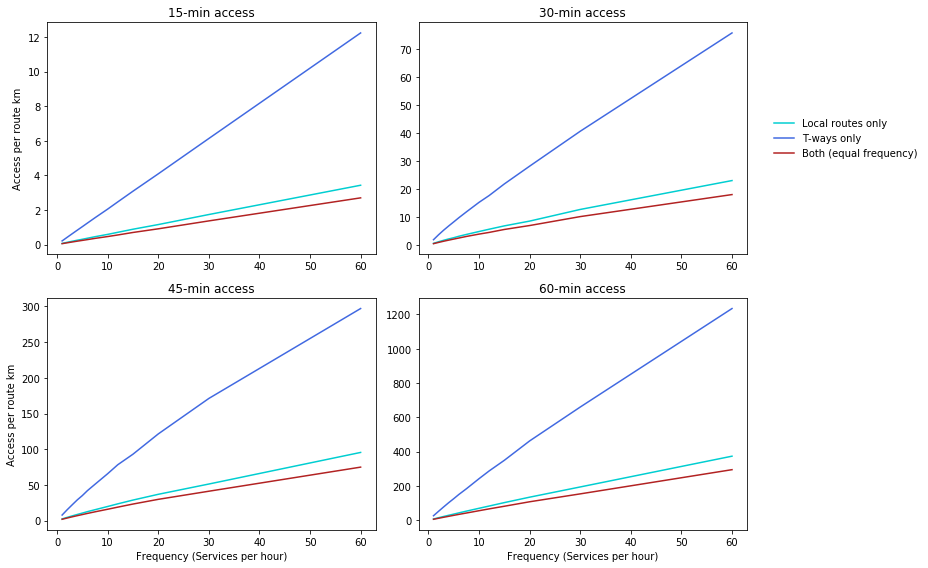

In [35]:
fig, ax = plt.subplots(nrows=2,ncols=2,figsize=(13,8))

ax[0,0].plot(localdf.index, localdf['15'], label='Local routes only', c='darkturquoise')
ax[0,0].plot(twaydf.index, twaydf['15'], label='T-ways only', c='royalblue')
ax[0,0].plot(diagonaldf.index, diagonaldf['15'], label='Both (equal frequency)', c='firebrick')
ax[0,0].set_ylabel('Access per route km')
# ax[0,0].set_ylim(0,1500)
ax[0,0].set_title('15-min access')

ax[0,1].plot(localdf.index, localdf['30'], label='Local routes only', c='darkturquoise')
ax[0,1].plot(twaydf.index, twaydf['30'], label='T-ways only', c='royalblue')
ax[0,1].plot(diagonaldf.index, diagonaldf['30'], label='Both (equal frequency)', c='firebrick')
# ax[0,1].set_ylim(0,1500)
ax[0,1].set_title('30-min access')
lgd = ax[0,1].legend(bbox_to_anchor=(1.3,0.5), loc='center', frameon=False)

ax[1,0].plot(localdf.index, localdf['45'], label='Local routes only', c='darkturquoise')
ax[1,0].plot(twaydf.index, twaydf['45'], label='T-ways only', c='royalblue')
ax[1,0].plot(diagonaldf.index, diagonaldf['45'], label='Both (equal frequency)', c='firebrick')
ax[1,0].set_ylabel('Access per route km')
ax[1,0].set_xlabel('Frequency (Services per hour)')
# ax[1,0].set_ylim(0,1500)
ax[1,0].set_title('45-min access')

ax[1,1].plot(localdf.index, localdf['60'], label='Local routes only', c='darkturquoise')
ax[1,1].plot(twaydf.index, twaydf['60'], label='T-ways only', c='royalblue')
ax[1,1].plot(diagonaldf.index, diagonaldf['60'], label='Both (equal frequency)', c='firebrick')
ax[1,1].set_xlabel('Frequency (Services per hour)')
# ax[1,1].set_ylim(0,1500)
ax[1,1].set_title('60-min access')

fig.tight_layout()
plt.show()
# fig.savefig('./Plots/AccessPerRouteKm_AllFrequencies_Yconst.pdf', bbox_extra_artists=(lgd,), bbox_inches='tight')
fig.savefig('./Plots/AccessPerRouteKm_AllFrequencies.pdf', bbox_extra_artists=(lgd,), bbox_inches='tight')


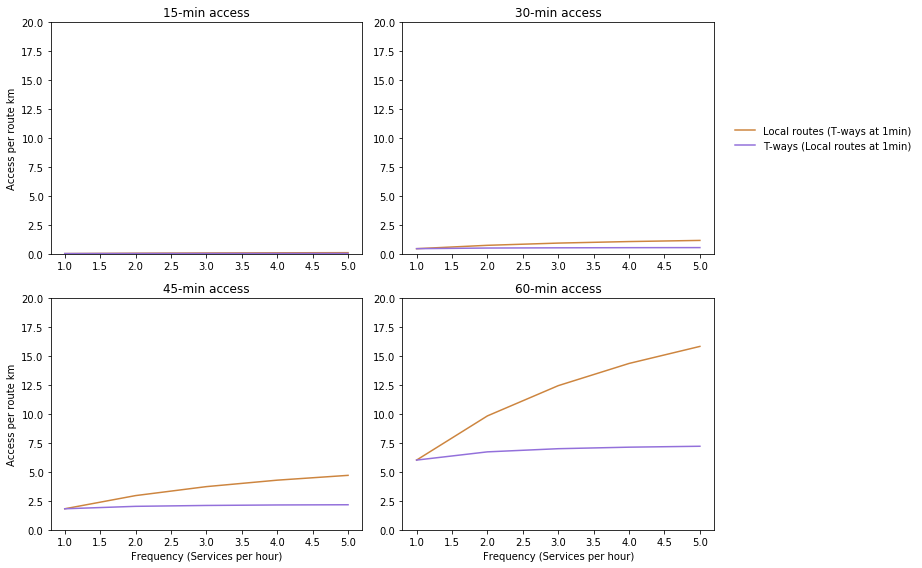

In [34]:
fig, ax = plt.subplots(nrows=2,ncols=2,figsize=(13,8))

ax[0,0].plot(lvar_t_one.index, lvar_t_one['15'], label='Local routes (T-ways at 1min)', c='peru')
ax[0,0].plot(tvar_l_one.index, tvar_l_one['15'], label='T-ways (Local routes at 1min)', c='mediumpurple')
ax[0,0].set_ylabel('Access per route km')
ax[0,0].set_ylim(0,20)
ax[0,0].set_title('15-min access')

ax[0,1].plot(lvar_t_one.index, lvar_t_one['30'], label='Local routes (T-ways at 1min)', c='peru')
ax[0,1].plot(tvar_l_one.index, tvar_l_one['30'], label='T-ways (Local routes at 1min)', c='mediumpurple')
ax[0,1].set_ylim(0,20)
ax[0,1].set_title('30-min access')
lgd = ax[0,1].legend(bbox_to_anchor=(1.35, 0.5), loc='center', frameon=False)


ax[1,0].plot(lvar_t_one.index, lvar_t_one['45'], label='Local routes (T-ways at 1min)', c='peru')
ax[1,0].plot(tvar_l_one.index, tvar_l_one['45'], label='T-ways (Local routes at 1min)', c='mediumpurple')
ax[1,0].set_ylabel('Access per route km')
ax[1,0].set_xlabel('Frequency (Services per hour)')
ax[1,0].set_ylim(0,20)
ax[1,0].set_title('45-min access')

ax[1,1].plot(lvar_t_one.index, lvar_t_one['60'], label='Local routes (T-ways at 1min)', c='peru')
ax[1,1].plot(tvar_l_one.index, tvar_l_one['60'], label='T-ways (Local routes at 1min)', c='mediumpurple')
ax[1,1].set_xlabel('Frequency (Services per hour)')
ax[1,1].set_ylim(0,20)
ax[1,1].set_title('60-min access')

fig.tight_layout()
plt.show()
fig.savefig('./Plots/AccessPerRouteKm_FixVar_Yconst.pdf', bbox_extra_artists=(lgd,), bbox_inches='tight')
# fig.savefig('./Plots/AccessPerRouteKm_FixVar.pdf', bbox_extra_artists=(lgd,), bbox_inches='tight')